### Homework 1:

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Here, I will first run the data that we are using so we can see each column name and what it contains. 

In [93]:
df = pd.read_csv('global_development.csv')
df.head()

,Country,Year,Birth Rate,Death Rate,Fertility Rate,"Life Expectancy at Birth, Total",Population Growth,Total Population,Agricultural Land Percent,Land Area,Rural Population Growth,Population Density,Urban Population Percent
0,Canada,1980,15.4,7.0,1.754,74.866341,0.997669,24277000.0,7.357225,9093510.0,0.833712,2.669706,75.623
1,Canada,1981,15.4,7.1,1.740,75.078049,1.293245,24593000.0,7.301471,9093510.0,1.129019,2.704456,75.663
2,Canada,1982,15.3,7.0,1.700,75.478537,1.240595,24900000.0,7.245717,9093510.0,1.039060,2.738217,75.712
3,Canada,1983,15.1,7.1,1.690,75.680488,1.205555,25202000.0,7.288275,9093510.0,0.536333,2.771427,75.874
4,Canada,1984,15.0,7.0,1.680,76.036341,1.002812,25456000.0,7.330943,9093510.0,0.333231,2.799359,76.035


### Figure 1:
- Displays the average global fertility rate by year in the data as a time series.
- Plot a confidence interval around averages (95%)
- CI(x) = 1.96 * (Standard deviation / (sqrt(sample size)) 

In [94]:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html

Text(0.5, 1.0, 'Global Fertility Rate by Year')

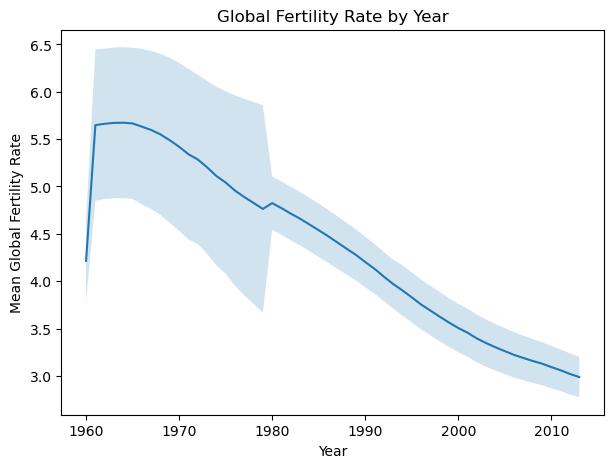

In [95]:
mean = df.groupby('Year')['Fertility Rate'].mean().reset_index()
# Year, Fertility Rate

std = df.groupby('Year')['Fertility Rate'].std().reset_index()

sample = df.groupby('Year')['Fertility Rate'].count().reset_index()

figure1 = mean.merge(std, on = 'Year').merge(sample, on = 'Year')

# here, now we have the mean, std, sample size, and now need to compute the CI function

figure1.rename(columns = {'Fertility Rate_x': 'Fertility Rate Mean', 'Fertility Rate_y': 'Fertility Rate Std',
                          'Fertility Rate': 'Fertility Rate size'}, inplace = True)
# figure1.head()
figure1['CI'] = 1.96 * ( figure1['Fertility Rate Std'] / np.sqrt(figure1['Fertility Rate size']) )

# figure1.head()


plt.figure(figsize = (7, 5))
plt.plot(figure1['Year'], figure1['Fertility Rate Mean'])

plt.fill_between(figure1['Year'],
                 figure1['Fertility Rate Mean'] - figure1['CI'],
                 figure1['Fertility Rate Mean'] + figure1['CI'],
                alpha = 0.2)

plt.xlabel('Year')
plt.ylabel('Mean Global Fertility Rate')
plt.title('Global Fertility Rate by Year')

### Figure 2:
- Some transparency to the points.
- Points scale by total population.
- Legend is correct.
- May need to rescale the population to be bounded on some range of point sizes for the legend.

In [96]:
df.head()

,Country,Year,Birth Rate,Death Rate,Fertility Rate,"Life Expectancy at Birth, Total",Population Growth,Total Population,Agricultural Land Percent,Land Area,Rural Population Growth,Population Density,Urban Population Percent
0,Canada,1980,15.4,7.0,1.754,74.866341,0.997669,24277000.0,7.357225,9093510.0,0.833712,2.669706,75.623
1,Canada,1981,15.4,7.1,1.740,75.078049,1.293245,24593000.0,7.301471,9093510.0,1.129019,2.704456,75.663
2,Canada,1982,15.3,7.0,1.700,75.478537,1.240595,24900000.0,7.245717,9093510.0,1.039060,2.738217,75.712
3,Canada,1983,15.1,7.1,1.690,75.680488,1.205555,25202000.0,7.288275,9093510.0,0.536333,2.771427,75.874
4,Canada,1984,15.0,7.0,1.680,76.036341,1.002812,25456000.0,7.330943,9093510.0,0.333231,2.799359,76.035


Text(0, 0.5, 'Population Growth Rate')

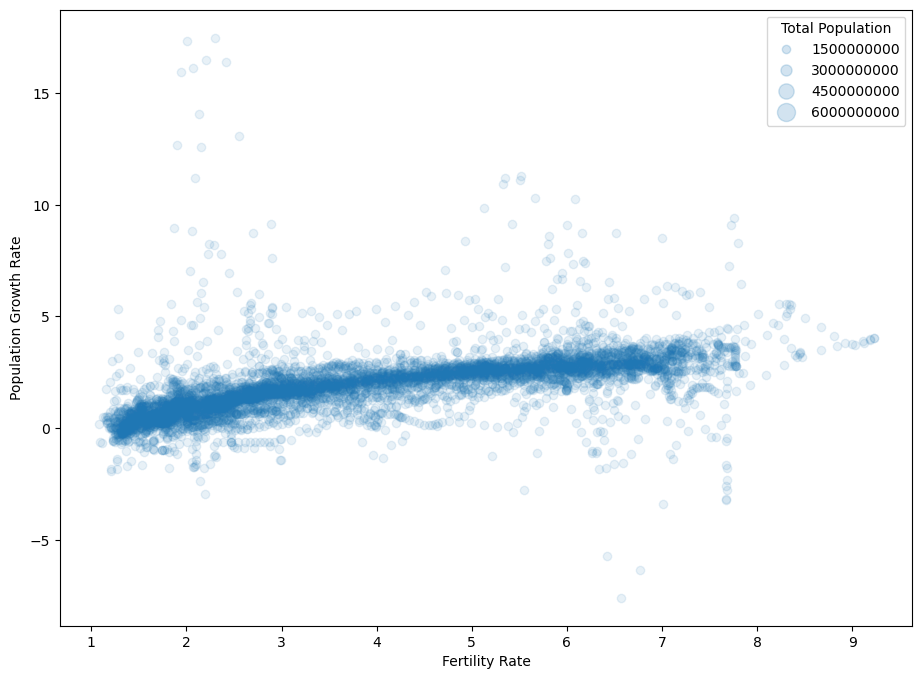

In [97]:
plt.figure(figsize = (11, 8))


plt.scatter(df['Fertility Rate'], df['Population Growth'], alpha = 0.1)


sizes = [1500000000, 3000000000, 4500000000, 6000000000]
labels = ['1500000000', '3000000000', '4500000000', '6000000000']


legend1 = plt.Line2D([0], [0], marker = 'o',linestyle = 'None', markersize = 6, alpha = 0.2)
legend2 = plt.Line2D([0], [0], marker = 'o',linestyle = 'None', markersize = 8, alpha = 0.2)
legend3 = plt.Line2D([0], [0], marker = 'o',linestyle = 'None', markersize = 11, alpha = 0.2)
legend4 = plt.Line2D([0], [0], marker = 'o',linestyle = 'None', markersize = 13, alpha = 0.2)

plt.legend(handles = [legend1, legend2, legend3, legend4], labels = labels, title = 'Total Population')

plt.xlabel('Fertility Rate')
plt.ylabel('Population Growth Rate')

### FIGURE 3
- Repliacte seaborn's pairplot function
- fine to use histograms instead of KDE's for the diagonal distributions

In [98]:
df.head()

,Country,Year,Birth Rate,Death Rate,Fertility Rate,"Life Expectancy at Birth, Total",Population Growth,Total Population,Agricultural Land Percent,Land Area,Rural Population Growth,Population Density,Urban Population Percent
0,Canada,1980,15.4,7.0,1.754,74.866341,0.997669,24277000.0,7.357225,9093510.0,0.833712,2.669706,75.623
1,Canada,1981,15.4,7.1,1.740,75.078049,1.293245,24593000.0,7.301471,9093510.0,1.129019,2.704456,75.663
2,Canada,1982,15.3,7.0,1.700,75.478537,1.240595,24900000.0,7.245717,9093510.0,1.039060,2.738217,75.712
3,Canada,1983,15.1,7.1,1.690,75.680488,1.205555,25202000.0,7.288275,9093510.0,0.536333,2.771427,75.874
4,Canada,1984,15.0,7.0,1.680,76.036341,1.002812,25456000.0,7.330943,9093510.0,0.333231,2.799359,76.035


In [99]:
# fig, ax = plt.subplots(3, 3, figsize = (10, 8))
# ax[0, 0].hist(df['Fertility Rate'])
# ax[0, 1].scatter(df['Population Growth'], df['Fertility Rate'])
# ax[0, 2].scatter(df['Urban Population Percent'], df['Fertility Rate'])

# ax[1, 0].scatter(df['Fertility Rate'], df['Population Growth'])
# ax[1, 1].hist(df['Population Growth'])
# ax[1, 2].scatter(df['Urban Population Percent'], df['Population Growth'])

# ax[2, 0].scatter(df['Fertility Rate'], df['Urban Population Percent'])
# ax[2, 1].scatter(df['Population Growth'], df['Urban Population Percent'])
# ax[2, 2].hist(df['Urban Population Percent'])

In [100]:

# df['Country'.unique()
country = df[df['Country'].isin(['India', 'United States', 'Brazil'])]


country['Country'].unique()


array(['India', 'United States', 'Brazil'], dtype=object)

(array([25.,  9.,  0.,  0.,  6.,  6.,  6.,  8., 18., 24.]),
 array([22.736 , 28.5732, 34.4104, 40.2476, 46.0848, 51.922 , 57.7592,
        63.5964, 69.4336, 75.2708, 81.108 ]),
 <BarContainer object of 10 artists>)

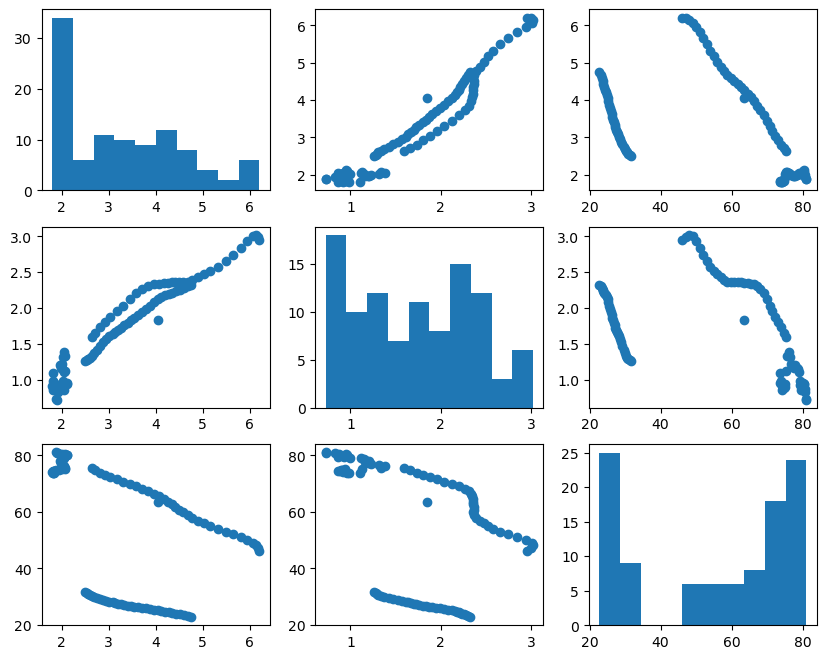

In [101]:
fig, ax = plt.subplots(3, 3, figsize = (10, 8))

ax[0,0].hist(country['Fertility Rate'])
ax[0, 1].scatter(country['Population Growth'], country['Fertility Rate'])
ax[0, 2].scatter(country['Urban Population Percent'], country['Fertility Rate'])

ax[1, 0].scatter(country['Fertility Rate'], country['Population Growth'])
ax[1, 1].hist(country['Population Growth'])
ax[1, 2].scatter(country['Urban Population Percent'], country['Population Growth'])

ax[2, 0].scatter(country['Fertility Rate'], country['Urban Population Percent'])
ax[2, 1].scatter(country['Population Growth'], country['Urban Population Percent'])
ax[2, 2].hist(country['Urban Population Percent'])

# need to filter each country then color code them 


In [102]:
# I 100% overcomplicated this and made it really long, there is definitely a shorter way to do this

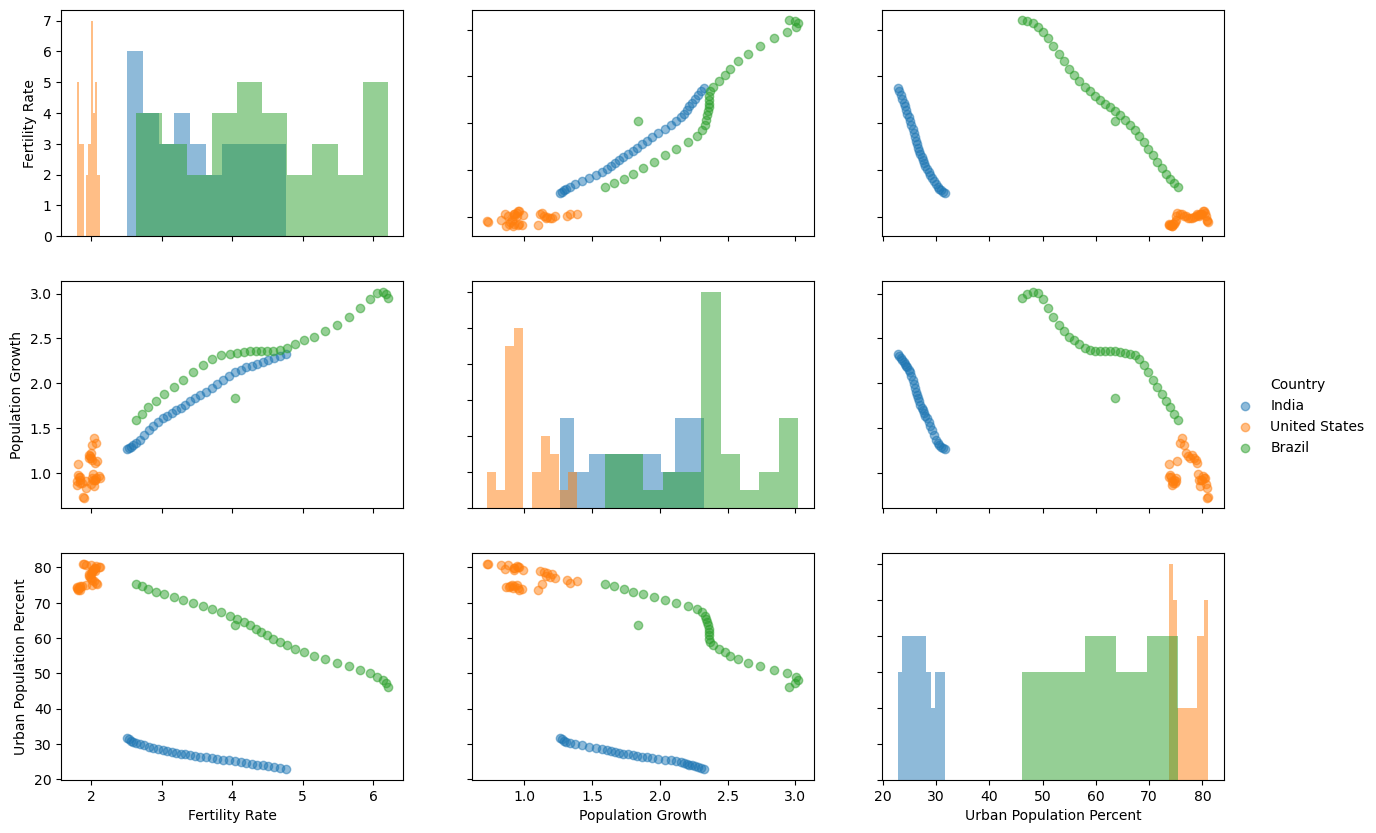

In [103]:
usa = country[country['Country'] == 'United States']
india = country[country['Country'] == 'India']
brazil = country[country['Country'] == 'Brazil']


fig, ax = plt.subplots(3, 3, figsize = (15, 10))

ax[0, 0].hist(india['Fertility Rate'], alpha = 0.5)
ax[0, 0].hist(usa['Fertility Rate'], alpha = 0.5)
ax[0, 0].hist(brazil['Fertility Rate'], alpha = 0.5)
ax[0, 0].set_ylabel('Fertility Rate')
ax[0, 0].set_xticklabels([])

ax[0, 1].scatter(india['Population Growth'], india['Fertility Rate'], alpha = 0.5, label = 'India')
ax[0, 1].scatter(usa['Population Growth'], usa['Fertility Rate'], alpha = 0.5, label = 'United States')
ax[0, 1].scatter(brazil['Population Growth'], brazil['Fertility Rate'], alpha = 0.5, label = 'Brazil')
ax[0, 1].set_xticklabels([])
ax[0, 1].set_yticklabels([])

ax[0, 2].scatter(india['Urban Population Percent'], india['Fertility Rate'], alpha = 0.5)
ax[0, 2].scatter(usa['Urban Population Percent'], usa['Fertility Rate'], alpha = 0.5)
ax[0, 2].scatter(brazil['Urban Population Percent'], brazil['Fertility Rate'], alpha = 0.5)
ax[0, 2].set_xticklabels([])
ax[0, 2].set_yticklabels([])


ax[1, 0].scatter(india['Fertility Rate'], india['Population Growth'], alpha = 0.5)
ax[1, 0].scatter(usa['Fertility Rate'], usa['Population Growth'], alpha = 0.5)
ax[1, 0].scatter(brazil['Fertility Rate'], brazil['Population Growth'], alpha = 0.5)
ax[1, 0].set_ylabel('Population Growth')
ax[1, 0].set_xticklabels([])

ax[1, 1].hist(india['Population Growth'], alpha = 0.5)
ax[1, 1].hist(usa['Population Growth'], alpha = 0.5)
ax[1, 1].hist(brazil['Population Growth'], alpha = 0.5)
ax[1, 1].set_xticklabels([])
ax[1, 1].set_yticklabels([])

ax[1, 2].scatter(india['Urban Population Percent'], india['Population Growth'], alpha = 0.5)
ax[1, 2].scatter(usa['Urban Population Percent'], usa['Population Growth'], alpha = 0.5)
ax[1, 2].scatter(brazil['Urban Population Percent'], brazil['Population Growth'], alpha = 0.5)
ax[1, 2].set_xticklabels([])
ax[1, 2].set_yticklabels([])


ax[2, 0].scatter(india['Fertility Rate'], india['Urban Population Percent'], alpha = 0.5)
ax[2, 0].scatter(usa['Fertility Rate'], usa['Urban Population Percent'], alpha = 0.5)
ax[2, 0].scatter(brazil['Fertility Rate'], brazil['Urban Population Percent'], alpha = 0.5)
ax[2 ,0].set_xlabel('Fertility Rate') # x label
ax[2, 0].set_ylabel('Urban Population Percent')

ax[2, 1].scatter(india['Population Growth'], india['Urban Population Percent'], alpha = 0.5)
ax[2, 1].scatter(usa['Population Growth'], usa['Urban Population Percent'], alpha = 0.5)
ax[2, 1].scatter(brazil['Population Growth'], brazil['Urban Population Percent'], alpha = 0.5)
ax[2, 1].set_xlabel('Population Growth') # x label
ax[2, 1].set_yticklabels([])

ax[2, 2].hist(india['Urban Population Percent'], alpha = 0.5)
ax[2, 2].hist(usa['Urban Population Percent'], alpha = 0.5)
ax[2, 2].hist(brazil['Urban Population Percent'], alpha = 0.5)
ax[2, 2].set_xlabel('Urban Population Percent') # x label
ax[2, 2].set_yticklabels([])

fig.legend(title = 'Country', loc = 'center right', frameon = False) #frameon False removes the box around it 
# plt.tight_layout()

In [ ]:
#this is just for me to see how easy seaborn makes it :')

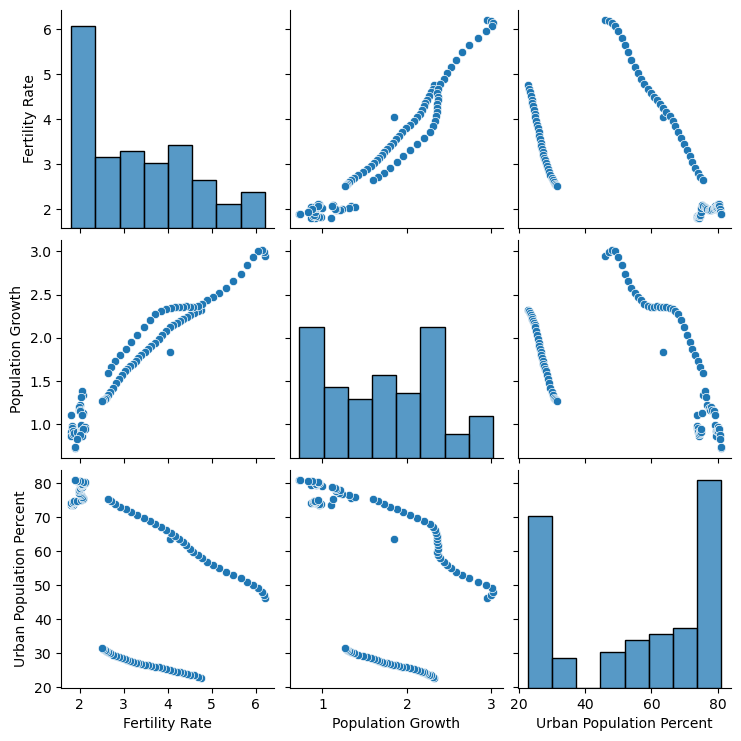

In [91]:
import seaborn as sns

sns.pairplot(country[['Fertility Rate', 'Population Growth', 'Urban Population Percent']])